<a href="https://colab.research.google.com/github/rg5139/GamerPsycheAnalytics/blob/main/DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import umap
from umap import UMAP

# =========================
# 0) Load
# =========================
gamers_csv = pd.read_csv("/content/cleaned_gamers_dataset.csv").copy()

print("Rows, Cols:", gamers_csv.shape)
print("Nulls (top 15):")
print(gamers_csv.isna().sum().sort_values(ascending=False).head(15))




Rows, Cols: (13407, 80)
Nulls (top 15):
Degree_original             1571
Degree                      1571
GADE                         647
earnings_subcluster          314
Birthplace_ISO3              120
Birthplace_ISO3_ISO3         120
Birthplace_ISO3_Numeric      120
Birthplace_ISO3_original     120
Residence_ISO3               109
Residence_ISO3_ISO3          109
Residence_ISO3_original      109
Residence_ISO3_Numeric       109
Hours                         30
GAD4                           0
S. No.                         0
dtype: int64


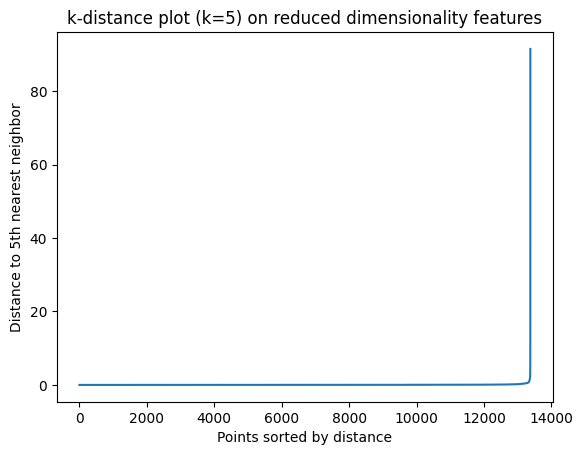

In [6]:
# gamers_csv["streams_log1p"] = np.log1p(gamers_csv["streams"])
# =========================
# 3) Pick eps using k-distance plot
# =========================
dbscan_features = [
    "Hours",
    "Playstyle_enum",   # your scaled rank score
    "whyplay_winning",
    "whyplay_improving",
    "whyplay_having_fun",
    "whyplay_relaxing",
    "whyplay_combined",
    "whyplay_novel",
    "streams"
]

gamers_csv = gamers_csv[dbscan_features].dropna()
X = gamers_csv
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_scaled)

min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples, metric="euclidean").fit(X_reduced)
distances, _ = nbrs.kneighbors(X_reduced)

# distance to the k-th nearest neighbor
kdist = np.sort(distances[:, 4])

plt.figure()
plt.plot(kdist)
plt.title(f"k-distance plot (k={min_samples}) on reduced dimensionality features")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.xlabel("Points sorted by distance")
plt.show()




In [7]:
# =========================
# 4) Run DBSCAN
# =========================
eps_guess = float(np.quantile(kdist, 0.98))
print("eps_guess (98th pct of k-dist):", eps_guess)

db = DBSCAN(eps=eps_guess, min_samples=min_samples, metric="euclidean")
labels = db.fit_predict(X_reduced)

gamers_csv["dbscan_cluster"] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_rate = (labels == -1).mean()

print("\nDBSCAN clusters (excluding noise):", n_clusters)
print(f"Noise rate:, {noise_rate:.3f}")
print(gamers_csv["dbscan_cluster"].value_counts())


eps_guess (98th pct of k-dist): 0.27629335048820325

DBSCAN clusters (excluding noise): 32
Noise rate:, 0.015
dbscan_cluster
 6     2722
 7     1815
 15    1706
 1     1263
 2     1067
 12    1021
 5      856
 14     724
 16     386
 0      342
 11     217
 3      203
 13     203
-1      199
 4      115
 17     115
 9      106
 10      88
 24      82
 18      33
 8       26
 22      13
 20      11
 25       9
 29       9
 27       8
 26       7
 19       6
 23       6
 31       6
 21       5
 30       5
 28       3
Name: count, dtype: int64


In [8]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_clusters

32

In [12]:
# =========================
# 5) Basic validation (silhouette excluding noise)
# =========================
mask = labels != -1
if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
    sil = silhouette_score(X_scaled[mask], labels[mask])
    print("Silhouette (excluding noise):", sil)
else:
    print("Silhouette not defined (need >=2 clusters and non-noise points).")



Silhouette (excluding noise): 0.31804435299829786


In [13]:
# =========================
# 6) Interpret clusters: size + means on key variables
# =========================
print("\nCluster sizes:")
print(gamers_csv["dbscan_cluster"].value_counts().sort_index())

CLUSTER_COL = "dbscan_cluster"

# 1) Cluster sizes (including noise)
sizes = gamers_csv[CLUSTER_COL].value_counts(dropna=False).sort_index()
n_total = len(gamers_csv)
summary = (
    sizes.rename("n")
    .to_frame()
    .assign(pct=lambda d: (d["n"] / n_total).round(4))
)
print("\nCluster sizes (incl. noise):")
print(summary)

# 2) Define interpretation columns by role (only keep those that exist)
interpret_blocks = {
    "Intensity": [
        "Hours",
        "streams",
    ],
    "Competitive orientation": [
        "avg_rank_score_scaled",
        "whyplay_winning",
        "whyplay_improving",
    ],
    "Motivation": [
        "whyplay_relaxing",
        "whyplay_having_fun",
    ],
    "Psych outcomes (profile only)": [
        "GAD_T",
        "SWL_T",
        "SPIN_T_imputed",
    ],
    "Demographics (optional)": [
        "Age",
        "Gender",
    ],
}

# Flatten + filter to existing cols
profile_cols = [c for block in interpret_blocks.values() for c in block if c in gamers_csv.columns]

# 3) Cluster profile table (exclude noise)
df_non_noise = gamers_csv.loc[gamers_csv[CLUSTER_COL] != -1, [CLUSTER_COL] + profile_cols].copy()

# Helpful: treat 0/1 flags differently (mean = share of cluster)
binary_cols = [c for c in profile_cols if set(df_non_noise[c].dropna().unique()).issubset({0, 1})]
numeric_cols = [c for c in profile_cols if c not in binary_cols]

agg_numeric = {c: ["mean", "median"] for c in numeric_cols}
agg_binary = {c: ["mean"] for c in binary_cols}  # mean == proportion == share with flag
agg = {**agg_numeric, **agg_binary, **{"Hours": []}}  # placeholder (no-op if not present)

cluster_profile = df_non_noise.groupby(CLUSTER_COL).agg({**agg_numeric, **agg_binary})
cluster_profile[("meta", "count")] = df_non_noise.groupby(CLUSTER_COL).size()

# Order columns: meta first, then numeric, then binary
cluster_profile = cluster_profile.reindex(
    columns=pd.MultiIndex.from_tuples(
        [("meta", "count")]
        + [t for t in cluster_profile.columns if t != ("meta", "count")]
    )
).sort_index(axis=1)

print("\nCluster profile (non-noise):")
print(cluster_profile)

# 4) (Optional but recommended) Differences vs overall mean for quick persona signals
overall_means = df_non_noise[profile_cols].mean(numeric_only=True)
cluster_means = df_non_noise.groupby(CLUSTER_COL)[profile_cols].mean(numeric_only=True)

delta_vs_overall = (cluster_means - overall_means).round(3)
print("\nCluster mean deltas vs overall (non-noise):")
print(delta_vs_overall)



Cluster sizes:
dbscan_cluster
-1      199
 0      342
 1     1263
 2     1067
 3      203
 4      115
 5      856
 6     2722
 7     1815
 8       26
 9      106
 10      88
 11     217
 12    1021
 13     203
 14     724
 15    1706
 16     386
 17     115
 18      33
 19       6
 20      11
 21       5
 22      13
 23       6
 24      82
 25       9
 26       7
 27       8
 28       3
 29       9
 30       5
 31       6
Name: count, dtype: int64

Cluster sizes (incl. noise):
                   n     pct
dbscan_cluster              
-1               199  0.0149
 0               342  0.0256
 1              1263  0.0944
 2              1067  0.0798
 3               203  0.0152
 4               115  0.0086
 5               856  0.0640
 6              2722  0.2035
 7              1815  0.1357
 8                26  0.0019
 9               106  0.0079
 10               88  0.0066
 11              217  0.0162
 12             1021  0.0763
 13              203  0.0152
 14              724  0.

In [14]:


umap_model = umap.UMAP(
    n_neighbors=15,     # local structure
    min_dist=0.1,       # cluster tightness
    n_components=2,
    random_state=42
)

embedding = umap_model.fit_transform(X_scaled)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


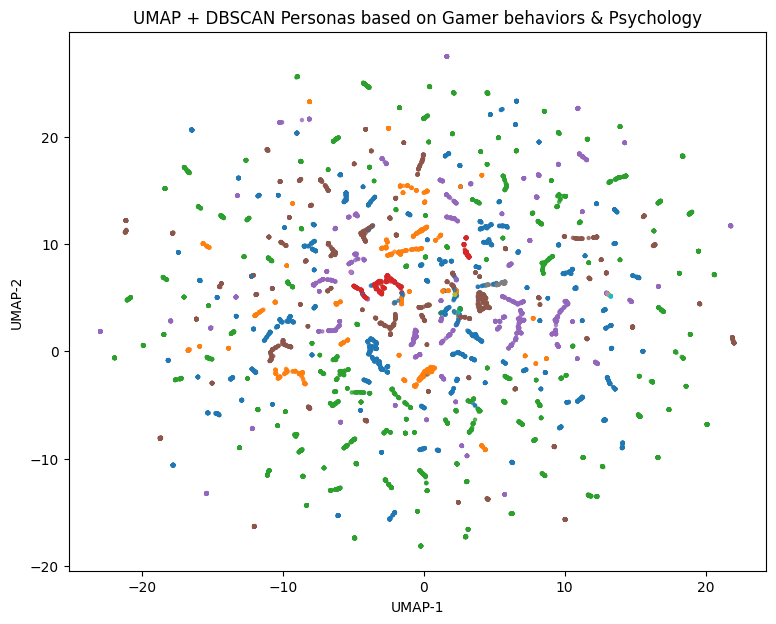

In [15]:
plt.figure(figsize=(9,7))
scatter = plt.scatter(embedding[:,0], embedding[:,1], c = labels, cmap="tab10", s=5, alpha=0.7)
plt.title("UMAP + DBSCAN Personas based on Gamer behaviors & Psychology")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

In [16]:
gamers_csv.describe()
df_full = pd.read_csv("/content/cleaned_gamers_dataset.csv").copy()
df_full["streams_log1p"] = np.log1p(df_full["streams"])
df_cluster = df_full[dbscan_features].dropna().copy()
df_cluster["dbscan_cluster"] = labels

In [17]:
df_full = df_full.merge(
    df_cluster[["dbscan_cluster"]],
    left_index=True,
    right_index=True,
    how="left"
)

In [18]:
psych_profile = (
    df_full[df_full["dbscan_cluster"] != -1]
    .groupby("dbscan_cluster")[["GAD_T", "SPIN_T_imputed", "SWL_T"]]
    .mean()
)

print(psych_profile)

                    GAD_T  SPIN_T_imputed      SWL_T
dbscan_cluster                                      
0.0              5.467836       22.935673  19.505848
1.0              4.917656       19.594616  19.749010
2.0              5.457357       19.876289  18.940956
3.0              5.773399       19.403941  20.408867
4.0              6.286957       21.260870  18.113043
5.0              6.484813       22.734813  17.811916
6.0              4.318148       18.262675  21.623439
7.0              4.980165       18.714601  20.555372
8.0              3.692308       15.076923  22.076923
9.0              4.915094       18.867925  20.216981
10.0             6.988636       22.159091  17.170455
11.0             6.396313       19.221198  18.944700
12.0             5.031342       20.671890  19.386876
13.0             5.285714       20.172414  18.876847
14.0             5.470994       20.846685  19.567680
15.0             5.457210       19.943142  19.171747
16.0             6.380829       21.966321  17.